In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [2]:
# Set device and seeds for reproducibility
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")

np.random.seed(42)
torch.manual_seed(42)

Using Device: cuda


In [3]:
LOOKBACK_GRID = [30, 60, 90]
HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.1
LR = 1e-3
EPOCHS = 120
TARGET_COVERAGE = 0.95
LAMBDA_WIDTH = 0.05

In [4]:
def load_and_prep_data(filepath="KO.csv"):
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip()
    
    df["Date"] = pd.to_datetime(df["Date"]).dt.tz_localize(None)
    df = df.sort_values("Date").reset_index(drop=True)
    
    # Feature Engineering
    df["log_return"] = np.log(df["Close"]).diff()
    df["volatility"] = df["log_return"].rolling(5).std()
    df["hl_range"] = (df["High"] - df["Low"]) / df["Close"]
    
    # Sentiment active impact
    df["sentiment_signed"] = 2 * (df["Scaled_sentiment"] - 0.5)
    df["sentiment_active"] = df["sentiment_signed"] * df["News_flag"]
    df["sentiment_impact"] = df["sentiment_active"] * df["log_return"].shift(1)
    
    df["target"] = df["Close"].shift(-1)
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    
    return df


In [5]:
def create_seq(X, y, dates, L):
    Xs, ys, ds = [], [], []
    for i in range(L, len(X)):
        Xs.append(X[i-L:i])
        ys.append(y[i])
        ds.append(dates.iloc[i])
    return np.array(Xs), np.array(ys), np.array(ds)

In [6]:
class GRUModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        # Changed from nn.RNN to nn.GRU
        self.gru = nn.GRU(input_size, HIDDEN_SIZE, NUM_LAYERS,
                          batch_first=True,
                          dropout=DROPOUT if NUM_LAYERS > 1 else 0)
        self.fc = nn.Linear(HIDDEN_SIZE, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :] # Take last time step
        return self.fc(out).squeeze()

def qloss(pred, y, q):
    """Quantile (Pinball) Loss"""
    e = y - pred
    return torch.mean(torch.maximum((q - 1) * e, q * e))

In [7]:
def train_and_predict(df, features, lookback, model_name="Model"):
    print(f"\n--- Training {model_name} (Lookback: {lookback}) ---")
    split = int(len(df) * 0.8)

    train_df = df.iloc[:split]
    
    scalerX = StandardScaler()
    scalerY = StandardScaler()

    scalerX.fit(train_df[features])
    scalerY.fit(train_df[["target"]])

    X = scalerX.transform(df[features])
    y = scalerY.transform(df[["target"]]).ravel()

    X_seq, y_seq, dates = create_seq(X, y, df["Date"], lookback)
    split_date = df["Date"].iloc[split]

    train_mask = dates < split_date
    test_mask = dates >= split_date

    X_train = torch.tensor(X_seq[train_mask], dtype=torch.float32).to(device)
    y_train = torch.tensor(y_seq[train_mask], dtype=torch.float32).to(device)

    X_test = torch.tensor(X_seq[test_mask], dtype=torch.float32).to(device)
    y_test = y_seq[test_mask]
    dates_test = dates[test_mask]

    def train_q(q, q_label):
        model = GRUModel(X_train.shape[2]).to(device) # Initializing GRU
        opt = torch.optim.Adam(model.parameters(), lr=LR)

        for epoch in range(EPOCHS):
            pred = model(X_train)
            loss = qloss(pred, y_train, q)

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            
            # Print Loss explicitly
            if (epoch + 1) % 40 == 0 or epoch == 0:
                print(f"[{q_label}] Epoch {epoch+1:03d}/{EPOCHS} | Loss: {loss.item():.4f}")

        return model

    model_low = train_q(0.025, "Low Quantile ")
    model_high = train_q(0.975, "High Quantile")

    with torch.no_grad():
        low = model_low(X_test).cpu().numpy()
        high = model_high(X_test).cpu().numpy()

    # Inverse scaling to actual prices
    low = scalerY.inverse_transform(low.reshape(-1, 1)).ravel()
    high = scalerY.inverse_transform(high.reshape(-1, 1)).ravel()
    y_true = scalerY.inverse_transform(y_test.reshape(-1, 1)).ravel()

    return low, high, y_true, dates_test

In [8]:
def calibrate(y, low, high):
    """Calibrate bounds to hit target coverage smoothly."""
    best_scale = 1
    best_score = 1e9

    for s in np.linspace(0.5, 2.0, 40):
        mid = (low + high) / 2
        l = mid - s * (mid - low)
        h = mid + s * (high - mid)

        cov = np.mean((y >= l) & (y <= h))
        width = np.mean(h - l)
        
        # Optimize for target coverage and minimal width
        score = abs(cov - TARGET_COVERAGE) + LAMBDA_WIDTH * width

        if score < best_score:
            best_score = score
            best_scale = s

    mid = (low + high) / 2
    cal_low = mid - best_scale * (mid - low)
    cal_high = mid + best_scale * (high - mid)

    return cal_low, cal_high

In [9]:
df = load_and_prep_data("KO.csv")

base_features = ["Close", "log_return", "volatility", "hl_range"]
sent_features = base_features + ["sentiment_active", "sentiment_impact"]

results = []
forecast_data = {} 

In [10]:

for L in LOOKBACK_GRID:
    low1, high1, y_true, dates = train_and_predict(df, base_features, L, "Base GRU Model")
    low2, high2, _, _ = train_and_predict(df, sent_features, L, "Sentiment GRU Model")

    low1, high1 = calibrate(y_true, low1, high1)
    low2, high2 = calibrate(y_true, low2, high2)

    mid1, mid2 = (low1 + high1) / 2, (low2 + high2) / 2
    
    cov1 = np.mean((y_true >= low1) & (y_true <= high1))
    cov2 = np.mean((y_true >= low2) & (y_true <= high2))

    width1, width2 = np.mean(high1 - low1), np.mean(high2 - low2)
    mse1, mse2 = mean_squared_error(y_true, mid1), mean_squared_error(y_true, mid2)

    results.append((L, cov1, width1, mse1, cov2, width2, mse2))
    
    forecast_data[L] = {
        'dates': dates, 'actual': y_true,
        'base_low': low1, 'base_high': high1, 'base_mid': mid1,
        'sent_low': low2, 'sent_high': high2, 'sent_mid': mid2
    }


--- Training Base GRU Model (Lookback: 30) ---
[Low Quantile ] Epoch 001/120 | Loss: 0.3554
[Low Quantile ] Epoch 040/120 | Loss: 0.0090
[Low Quantile ] Epoch 080/120 | Loss: 0.0064
[Low Quantile ] Epoch 120/120 | Loss: 0.0061
[High Quantile] Epoch 001/120 | Loss: 0.3306
[High Quantile] Epoch 040/120 | Loss: 0.0088
[High Quantile] Epoch 080/120 | Loss: 0.0056
[High Quantile] Epoch 120/120 | Loss: 0.0052

--- Training Sentiment GRU Model (Lookback: 30) ---
[Low Quantile ] Epoch 001/120 | Loss: 0.3570
[Low Quantile ] Epoch 040/120 | Loss: 0.0091
[Low Quantile ] Epoch 080/120 | Loss: 0.0063
[Low Quantile ] Epoch 120/120 | Loss: 0.0061
[High Quantile] Epoch 001/120 | Loss: 0.3828
[High Quantile] Epoch 040/120 | Loss: 0.0096
[High Quantile] Epoch 080/120 | Loss: 0.0055
[High Quantile] Epoch 120/120 | Loss: 0.0051

--- Training Base GRU Model (Lookback: 60) ---
[Low Quantile ] Epoch 001/120 | Loss: 0.3828
[Low Quantile ] Epoch 040/120 | Loss: 0.0093
[Low Quantile ] Epoch 080/120 | Loss: 0.0

In [11]:
print("\n" + "="*80)
print(f"{'FINAL COMPARISON (Base vs Sentiment - GRU)':^80}")
print("="*80)
print(f"{'Lookback':<10} | {'Base Cov':<10} | {'Base Wdth':<10} | {'Base MSE':<10} || {'Sent Cov':<10} | {'Sent Wdth':<10} | {'Sent MSE':<10}")
print("-" * 80)
for r in results:
    print(f"{r[0]:<10} | {r[1]:<10.4f} | {r[2]:<10.4f} | {r[3]:<10.4f} || {r[4]:<10.4f} | {r[5]:<10.4f} | {r[6]:<10.4f}")


                   FINAL COMPARISON (Base vs Sentiment - GRU)                   
Lookback   | Base Cov   | Base Wdth  | Base MSE   || Sent Cov   | Sent Wdth  | Sent MSE  
--------------------------------------------------------------------------------
30         | 0.9467     | 6.6899     | 4.0806     || 0.9327     | 6.5930     | 4.3031    
60         | 0.9285     | 6.2908     | 3.9996     || 0.9341     | 6.2687     | 3.8655    
90         | 0.9201     | 6.1491     | 4.1415     || 0.9369     | 6.2157     | 3.7592    


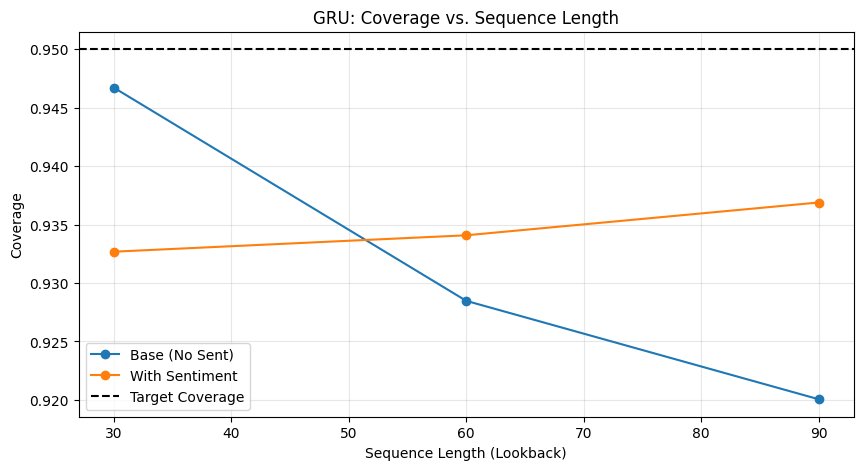

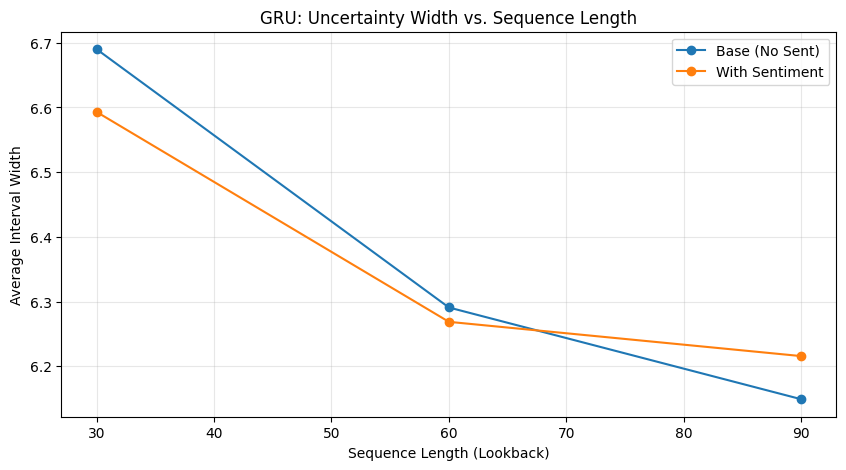

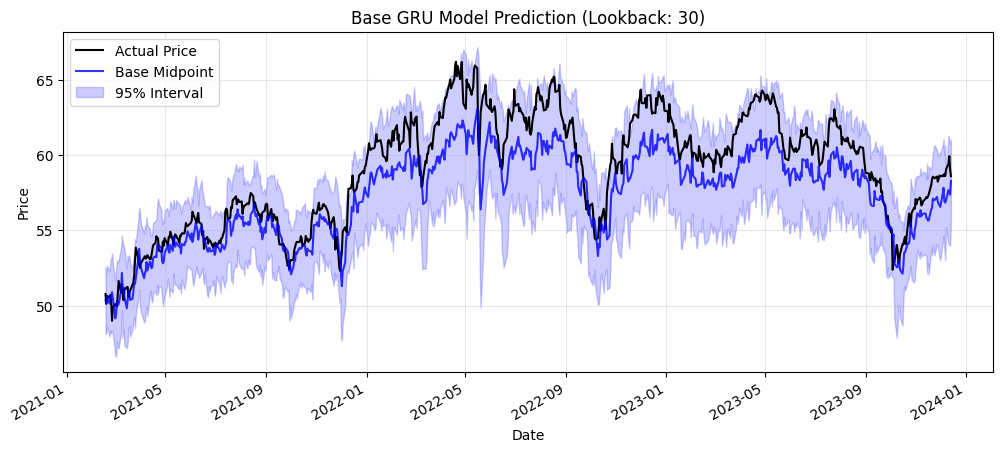

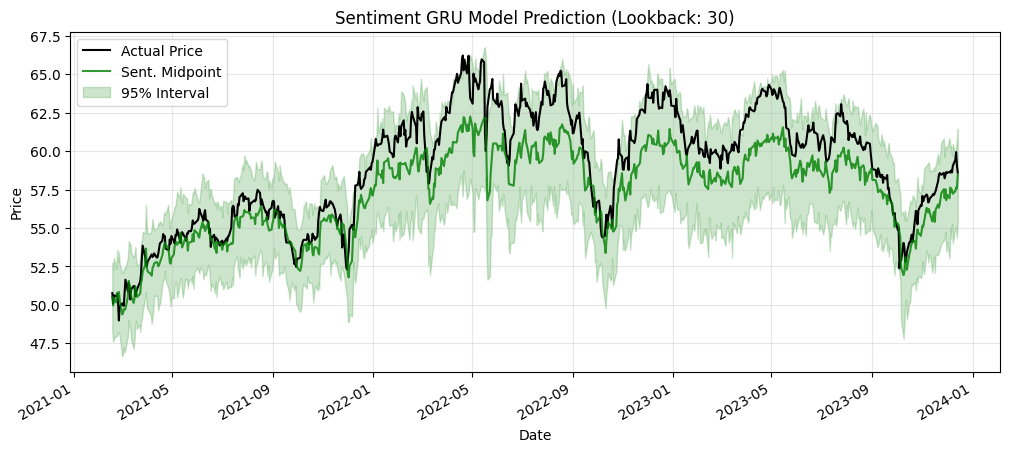

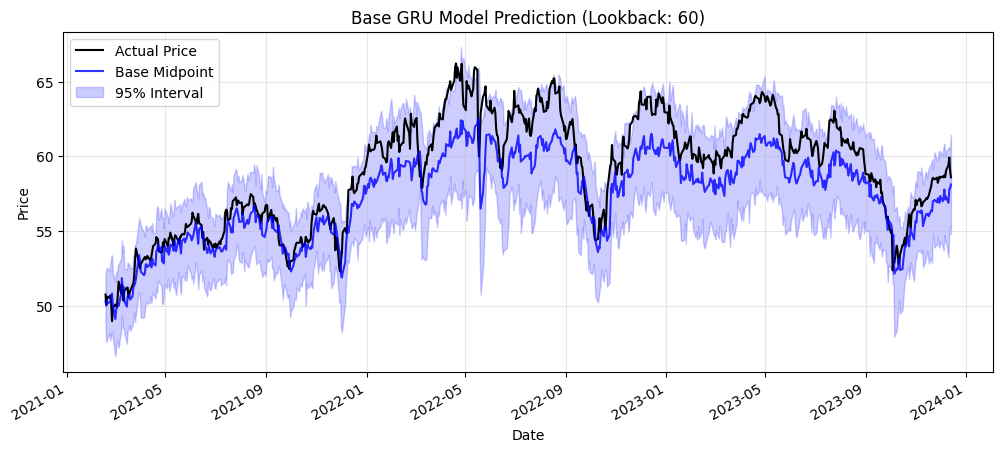

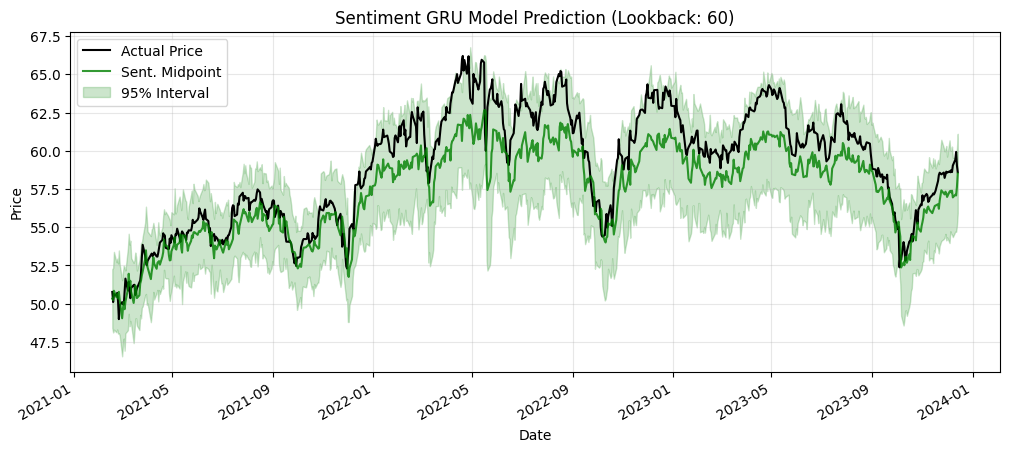

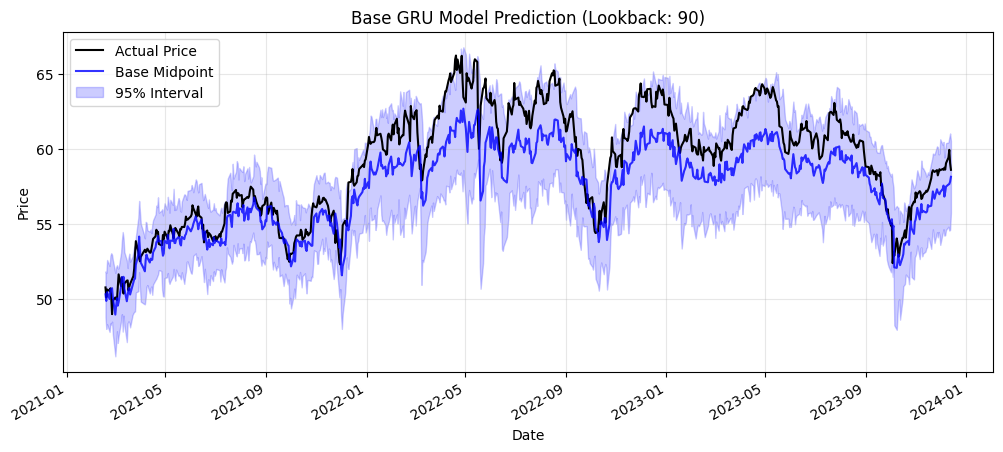

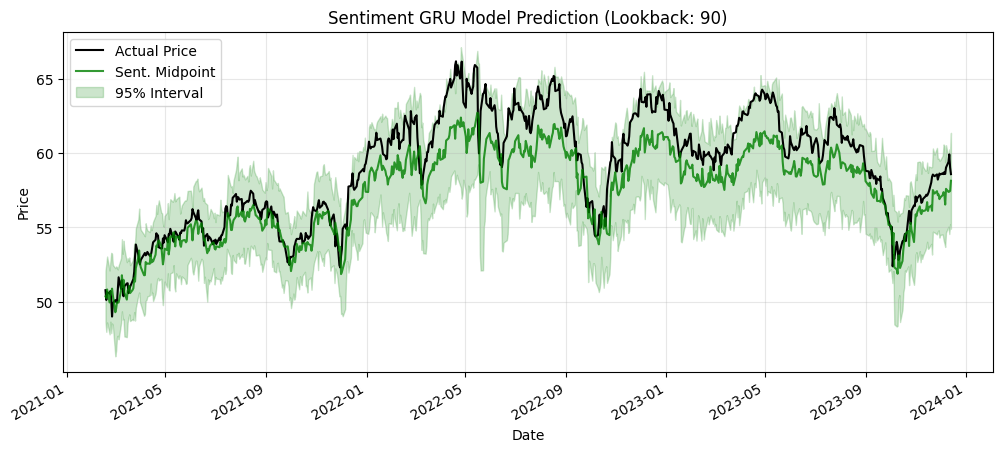

In [12]:
# 8. ESSENTIAL PLOTS (ONE BY ONE)
# Plot 1: Coverage vs Lookback
plt.figure(figsize=(10, 5))
plt.plot([r[0] for r in results], [r[1] for r in results], marker='o', label="Base (No Sent)")
plt.plot([r[0] for r in results], [r[4] for r in results], marker='o', label="With Sentiment")
plt.axhline(TARGET_COVERAGE, color='black', linestyle='--', label="Target Coverage")
plt.xlabel("Sequence Length (Lookback)")
plt.ylabel("Coverage")
plt.title("GRU: Coverage vs. Sequence Length")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() 

# Plot 2: Width vs Lookback
plt.figure(figsize=(10, 5))
plt.plot([r[0] for r in results], [r[2] for r in results], marker='o', label="Base (No Sent)")
plt.plot([r[0] for r in results], [r[5] for r in results], marker='o', label="With Sentiment")
plt.xlabel("Sequence Length (Lookback)")
plt.ylabel("Average Interval Width")
plt.title("GRU: Uncertainty Width vs. Sequence Length")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot 3...N: Forecast Visualizations for EACH model and EACH lookback individually
for L in LOOKBACK_GRID:
    data = forecast_data[L]
    # INDIVIDUAL CHART: Base Model
    plt.figure(figsize=(12, 5))
    plt.plot(data['dates'], data['actual'], label="Actual Price", color='black', linewidth=1.5)
    plt.plot(data['dates'], data['base_mid'], label="Base Midpoint", color='blue', alpha=0.8)
    plt.fill_between(data['dates'], data['base_low'], data['base_high'], color='blue', alpha=0.2, label="95% Interval")
    plt.title(f"Base GRU Model Prediction (Lookback: {L})")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.gcf().autofmt_xdate()
    plt.show()
    
    # INDIVIDUAL CHART: Sentiment Model
    
    plt.figure(figsize=(12, 5))
    plt.plot(data['dates'], data['actual'], label="Actual Price", color='black', linewidth=1.5)
    plt.plot(data['dates'], data['sent_mid'], label="Sent. Midpoint", color='green', alpha=0.8)
    plt.fill_between(data['dates'], data['sent_low'], data['sent_high'], color='green', alpha=0.2, label="95% Interval")
    plt.title(f"Sentiment GRU Model Prediction (Lookback: {L})")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.gcf().autofmt_xdate()
    plt.show()